# **GreenCompactor - Klasifikasi Jenis Sampah dengan CNN (4 Kelas)**

URL : https://github.com/hollandakusuma/GreenCompactor-Klasifikasi-Sampah

## 1. Latar Belakang & Motivasi

**GreenCompactor** adalah alat pemadatan dan penyortiran sampah yang dikembangkan oleh dosen dan mahasiswa Departemen Teknik Elektro, Universitas Maritim Raja Ali Haji (UMRAH). Alat ini dirancang untuk mendukung program kampus yang lebih hijau melalui manajemen sampah yang lebih efisien dan terarah.

Saat ini, GreenCompactor sudah mampu mendeteksi dan memilah material sampah dasar (plastik vs. logam) serta mengompresi sampah secara otomatis. Namun, untuk meningkatkan nilai ekonomis dari sampah yang dikumpulkan dan mengoptimalkan proses daur ulang, diperlukan identifikasi yang lebih detail mengenai **jenis spesifik** dari setiap item sampah yang masuk.

Proyek klasifikasi ini bertujuan untuk mengembangkan **model deep learning berbasis CNN** yang mampu mengidentifikasi 4 kategori sampah yang paling sering ditemukan di lingkungan kampus:

1. **Botol Plastik Bening (PET)** — botol air mineral, minuman bening
2. **Botol Plastik Berwarna** — botol minuman bersoda, jus, kemasan warna-warni
3. **Tutup Botol** — tutup plastik dari berbagai jenis botol
4. **Kaleng Minuman** — kaleng aluminium soda, kopi, energy drink

Dengan model ini, GreenCompactor dapat:
- Mengklasifikasi sampah masuk secara otomatis dengan akurasi tinggi (target ≥95%)
- Memisahkan sampah ke "bin" yang tepat untuk proses daur ulang lebih lanjut
- Meningkatkan nilai jual sampah berdasarkan jenis dan material (PET, HDPE, aluminium, dll memiliki harga jual yang berbeda)
- Mengumpulkan data statistik penggunaan sampah di kampus untuk program pengelolaan limbah yang lebih baik

---

## **2. Dataset & Metodologi Pengumpulan Data**

### **2.1 Sumber Data**

Dataset untuk proyek ini dikumpulkan dari **Web Scraping (Google Images)** dengan query spesifik per kelas:
- "botol air mineral bening plastik PET"
- "botol minuman berwarna soda Fanta Sprite Pulpy"
- "tutup botol plastik warna-warni"
- "kaleng minuman soda kopi aluminium"


### **2.2 Komposisi Dataset**

**Jumlah Gambar per Kelas:**
- Target awal: 120 gambar asli per kelas (480 total)
- Setelah augmentasi offline: 2.500 gambar per kelas (10.000 total)
- Augmentasi mencakup 20 jenis transformasi (flip, rotasi, resize, brightness, contrast, noise, shearing, grayscale, blur, random crop, dll)

**Penamaan File (Traceable):**
Setiap gambar asli (kode -00) menghasilkan 21 variasi (1 asli + 20 augmentasi):
```
gambar001-00.png  (asli)
gambar001-01.png  (flip horizontal)
gambar001-02.png  (flip vertikal)
...
gambar001-20.png  (random crop)
```


### **2.3 Pembagian Dataset**

Dataset dibagi menjadi tiga subset untuk melatih dan mengevaluasi model:

| Subset | Proporsi | Jumlah Gambar | Penggunaan |
|---|---|---|---|
| **Training** | 70% | 7.000 | Melatih parameter model |
| **Validation** | 15% | 1.500 | Monitoring performa saat training, tuning hyperparameter |
| **Testing** | 15% | 1.500 | Evaluasi final model pada data yang belum pernah dilihat |

Pembagian dilakukan secara **stratified** untuk memastikan distribusi kelas tetap seimbang di ketiga subset.

---

## **3. Arsitektur Model & Eksperimen**

Notebook ini melatih dan membandingkan **3 arsitektur CNN** yang berbeda, semua mengikuti kriteria submission (Sequential, Conv2D, Pooling):

### **Model A — Basic CNN (3 blok Conv+Pool)**
```
Input (160×160×3)
└─ Rescaling (1/255)
└─ Conv2D(16, 3×3) + ReLU + MaxPooling(2×2)
└─ Conv2D(32, 3×3) + ReLU + MaxPooling(2×2)
└─ Conv2D(64, 3×3) + ReLU + MaxPooling(2×2)
└─ Flatten
└─ Dense(128) + ReLU
└─ Dense(4) + Softmax
```
**Target:** baseline yang sederhana, cepat training, akurasi ~85%

### **Model B — Deeper CNN (4 blok Conv+Pool + Dropout)**
```
Input (160×160×3)
└─ Rescaling (1/255)
└─ Conv2D(32, 3×3) + ReLU + MaxPooling(2×2)
└─ Conv2D(64, 3×3) + ReLU + MaxPooling(2×2)
└─ Conv2D(128, 3×3) + ReLU + MaxPooling(2×2)
└─ Conv2D(128, 3×3) + ReLU + MaxPooling(2×2)
└─ Flatten
└─ Dense(256) + ReLU + Dropout(0.3)
└─ Dense(4) + Softmax
```
**Target:** pembelajaran fitur yang lebih dalam, regularisasi dengan Dropout, akurasi ~90%+

### **Model C — CNN dengan BatchNormalization**
```
Input (160×160×3)
└─ Rescaling (1/255)
└─ Conv2D(32, 3×3) + ReLU + BatchNormalization + MaxPooling(2×2)
└─ Conv2D(64, 3×3) + ReLU + BatchNormalization + MaxPooling(2×2)
└─ Conv2D(128, 3×3) + ReLU + BatchNormalization + MaxPooling(2×2)
└─ Flatten
└─ Dense(128) + ReLU + Dropout(0.4)
└─ Dense(4) + Softmax
```
**Target:** stabilitas training lebih baik dengan **BatchNormalization**, akurasi optimal ~93-95%

---

## **4. Callback & Training Configuration**

Untuk mencapai akurasi ≥95% dan menghindari *overfitting*, digunakan 3 callback standar:

| Callback | Fungsi |
|---|---|
| **EarlyStopping** | Menghentikan training jika validation accuracy tidak meningkat selama 5 epoch; restore weights dari epoch terbaik |
| **ReduceLROnPlateau** | Menurunkan learning rate sebesar 50% jika validation loss plateauing (tidak ada improvement 3 epoch), min_lr=1e-6 |
| **ModelCheckpoint** | Menyimpan model weights terbaik berdasarkan validation accuracy; hanya update jika ada peningkatan |

**Hyperparameter:**
- Optimizer: Adam (auto learning rate)
- Loss function: Categorical Crossentropy (multi-class classification)
- Batch size: 32
- Image size: 160×160 pixels
- Max epochs: 25

---

## **5. Preprocessing**

- **Rescaling (1/255):** normalisasi pixel intensity dari range [0, 255] ke [0, 1]

---

## **6. Hasil & Analisis**

Notebook akan menghasilkan:
1. **Perbandingan ketiga model** — tabel akurasi training, validation, dan testing
2. **Plot training history** — 2 grafik per model (akurasi & loss) untuk melihat kurva pembelajaran
3. **Model terbaik terpilih otomatis** berdasarkan test accuracy tertinggi
4. **Inference visualization** — 6 contoh gambar dari test set dengan prediksi model (warna hijau = benar, merah = salah) + confidence score

**Target akurasi:**
- Training ≥95%
- Validation ≥94%
- Testing ≥92-95%

Jika target ini tercapai, model siap untuk diterapkan pada alat GreenCompactor.

---

## **7. Ekspor & Deployment Format**

Model terbaik disimpan dalam **3 format** sesuai kriteria submission:

### **a) SavedModel (TensorFlow native format)**
- Format: `.pb` + `variables/` folder
- Kegunaan: deployment di server, cloud (GCP, AWS), atau sistem embedded yang bisa menjalankan TensorFlow
- Path: `submission/saved_model/`

### **b) TF-Lite (TensorFlow Lite)**
- Format: `.tflite` (binary, ~1-5 MB, sangat ringan)
- Kegunaan: deployment di mobile (Android/iOS), embedded devices (Raspberry Pi, microcontroller), IoT edge
- Plus: label file `label.txt` untuk interpretasi output
- Path: `submission/tflite/`

### **c) TFJS (TensorFlow.js)**
- Format: `model.json` + `group1-shard1of1.bin` (dapat dijalankan di browser/Node.js)
- Kegunaan: web application, dashboard monitoring real-time di browser
- Path: `submission/tfjs_model/`

---


## **1.   Install dependencies**



In [ ]:
!pip install -q split-folders tensorflowjs # untuk membagi dataset folder otomatis ke train / validation / test

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.42.1 requires packaging>=24.2.0, but you have pa

## **2.   Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **3.  Lokasi dataset**

Siapkan struktur folder di Google Drive seperti ini, lalu sesuaikan `DATASET_DIR` di bawah:

```
MyDrive/Colab Notebooks/
  Green Compactor/
      Botol Bening/
      Botol Warna/
      Tutup Botol/
      Kaleng/
```

Ganti nama folder di bawah kalau nama folder kamu di Drive berbeda.

In [ ]:
import os

DatasetDir = "/content/drive/MyDrive/Colab Notebooks/Green Compactor"  # ganti sesuai lokasi di Drive kamu
NamaKelas = ["Botol Bening", "Botol Warna", "Tutup Botol", "Kaleng"]  # ganti sesuai nama folder kamu

assert os.path.exists(DatasetDir), f"Folder tidak ditemukan: {DatasetDir}"
for c in NamaKelas:
    path = os.path.join(DatasetDir, c)
    assert os.path.exists(path), f"Folder kelas tidak ditemukan: {path}"
print("Semua folder kelas ditemukan.")

Semua folder kelas ditemukan.


## **4.   Hitung jumlah gambar per kelas**

In [ ]:
import glob

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

counts = {}
for c in NamaKelas:
    files = [f for f in glob.glob(os.path.join(DatasetDir, c, "*")) if f.lower().endswith(VALID_EXT)]
    counts[c] = len(files)

total = sum(counts.values())

print("Jumlah gambar per kelas:")
for c, n in counts.items():
    print(f"  {c:20s}: {n:6d} gambar")
print(f"  {'TOTAL':20s}: {total:6d} gambar")

Jumlah gambar per kelas:
  Botol Bening        :   2520 gambar
  Botol Warna         :   2520 gambar
  Tutup Botol         :   2520 gambar
  Kaleng              :   2520 gambar
  TOTAL               :  10080 gambar


## **5.   Split dataset menjadi Train / Validation / Test**

Menggunakan `split-folders` supaya pembagian dilakukan berdasarkan file fisik
(hasil split disalin ke folder baru), rasio 70% train / 15% validation / 15% test.

In [ ]:
import splitfolders
import os

SplitDir = os.path.join(DatasetDir, "Dataset Split")

splitfolders.ratio(
    DatasetDir,
    output=SplitDir,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None,
    move=False,
)

print("Selesai split. Struktur folder hasil split:")
for split in ["train", "val", "test"]:
    for c in NamaKelas:
        p = os.path.join(SplitDir, split, c)
        n = len(os.listdir(p)) if os.path.exists(p) else 0
        print(f"  {split:6s}/{c:20s}: {n} gambar")

Copying files: 10080 files [15:07, 11.10 files/s]


Selesai split. Struktur folder hasil split:
  train /Botol Bening        : 1764 gambar
  train /Botol Warna         : 1764 gambar
  train /Tutup Botol         : 1764 gambar
  train /Kaleng              : 1764 gambar
  val   /Botol Bening        : 378 gambar
  val   /Botol Warna         : 378 gambar
  val   /Tutup Botol         : 378 gambar
  val   /Kaleng              : 378 gambar
  test  /Botol Bening        : 378 gambar
  test  /Botol Warna         : 378 gambar
  test  /Tutup Botol         : 378 gambar
  test  /Kaleng              : 378 gambar


## **6.  Load dataset dengan `image_dataset_from_directory`**

In [ ]:
import tensorflow as tf

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SplitDir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SplitDir, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SplitDir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
print("Urutan kelas:", class_names)

# Prefetch untuk performa
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 7056 files belonging to 4 classes.
Found 1512 files belonging to 4 classes.
Found 1512 files belonging to 4 classes.
Urutan kelas: ['Botol Bening', 'Botol Warna', 'Kaleng', 'Tutup Botol']


## **7.  Lihat contoh gambar tiap kelas (sanity check)**

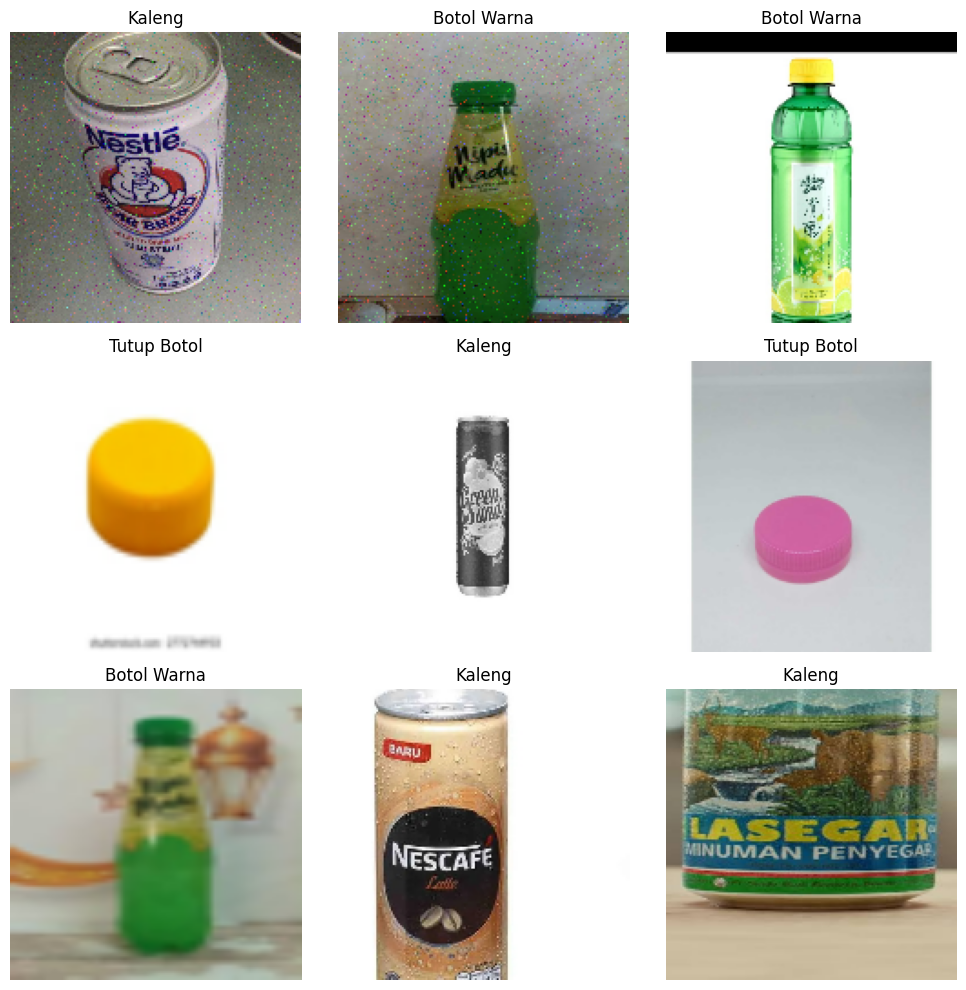

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

## **8.  Definisikan beberapa arsitektur CNN untuk dibandingkan**
1.   **Model A (Basic CNN):** Model dasar dengan 3 blok Convolutional dan Pooling. Tujuannya adalah untuk menjadi baseline yang sederhana, cepat dilatih, dengan target akurasi sekitar 85%.

2.   **Model B (Deeper CNN):** Model ini menggunakan 4 blok Convolutional dan Pooling dengan jumlah filter yang lebih besar. Juga menyertakan lapisan Dropout untuk regularisasi, bertujuan untuk pembelajaran fitur yang lebih dalam dan akurasi di atas 90%.

3.   **Model C (CNN with BatchNormalization):** Model ini mirip dengan Model B namun menambahkan lapisan Batch Normalization setelah setiap lapisan konvolusi. Batch Normalization membantu menstabilkan training dan mempercepat konvergensi, dengan target akurasi optimal 93-95%. Model ini juga menggunakan Dropout.

In [ ]:
from tensorflow.keras import layers, models

NUM_CLASSES = len(class_names)
INPUT_SHAPE = IMG_SIZE + (3,)


def build_model_a():
    # Model A: CNN dasar, 3 blok Conv+Pool
    model = models.Sequential([
        layers.Rescaling(1.0 / 255, input_shape=INPUT_SHAPE),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="model_a_basic")
    return model


def build_model_b():
    # Model B: 4 blok Conv+Pool, filter lebih besar
    model = models.Sequential([
        layers.Rescaling(1.0 / 255, input_shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="model_b_deeper")
    return model


def build_model_c():
    # Model C: pakai BatchNormalization untuk stabilitas training
    model = models.Sequential([
        layers.Rescaling(1.0 / 255, input_shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="model_c_batchnorm")
    return model


model_builders = {
    "Model A (Basic)": build_model_a,
    "Model B (Deeper)": build_model_b,
    "Model C (BatchNorm)": build_model_c,
}

## **9.  Callback**

Dipakai untuk ketiga model: `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`.

In [ ]:
def get_callbacks(checkpoint_path):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_accuracy", save_best_only=True
        ),
    ]

## **10.  Latih dan bandingkan ketiga model**

In [ ]:
# Definisikan Epoch yang digunakan
EPOCHS = 25

# Inisialisasi variabel untuk menyimpan hasil
histories = {}
results = {}

In [ ]:
for name, builder in model_builders.items():
    print("=" * 60)
    print(f"Training {name}")
    print("=" * 60)

    model = builder()
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    ckpt_path = f"/content/checkpoint_{name.split()[0]}_{name.split()[1].strip('()')}.keras"
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(ckpt_path),
        verbose=1,
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\n{name} -> Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

    histories[name] = history
    results[name] = {"model": model, "test_acc": test_acc, "test_loss": test_loss, "ckpt": ckpt_path}

Training Model A (Basic)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 158s 627ms/step - accuracy: 0.7421 - loss: 0.6735 - val_accuracy: 0.8347 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 2/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 171s 563ms/step - accuracy: 0.8885 - loss: 0.3189 - val_accuracy: 0.8869 - val_loss: 0.3453 - learning_rate: 0.0010
Epoch 3/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 125s 567ms/step - accuracy: 0.9262 - loss: 0.2122 - val_accuracy: 0.9153 - val_loss: 0.2651 - learning_rate: 0.0010
Epoch 4/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 140s 632ms/step - accuracy: 0.9538 - loss: 0.1433 - val_accuracy: 0.8896 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 5/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 122s 552ms/step - accuracy: 0.9615 - loss: 0.1137 - val_accuracy: 0.9266 - val_loss: 0.2900 - learning_rate: 0.0010
Epoch 6/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 141s 640ms/step - accuracy: 0.9715 - loss: 0.0832 - val_accuracy: 0.9319 - val_loss: 0.3170 - learning_rate: 0.0010
Epoch 7/25
221/221 ━━━━━━━━━━━━━━━━━━━━ 123s 554ms/step - accura

## **11.   Plot akurasi & loss tiap model**

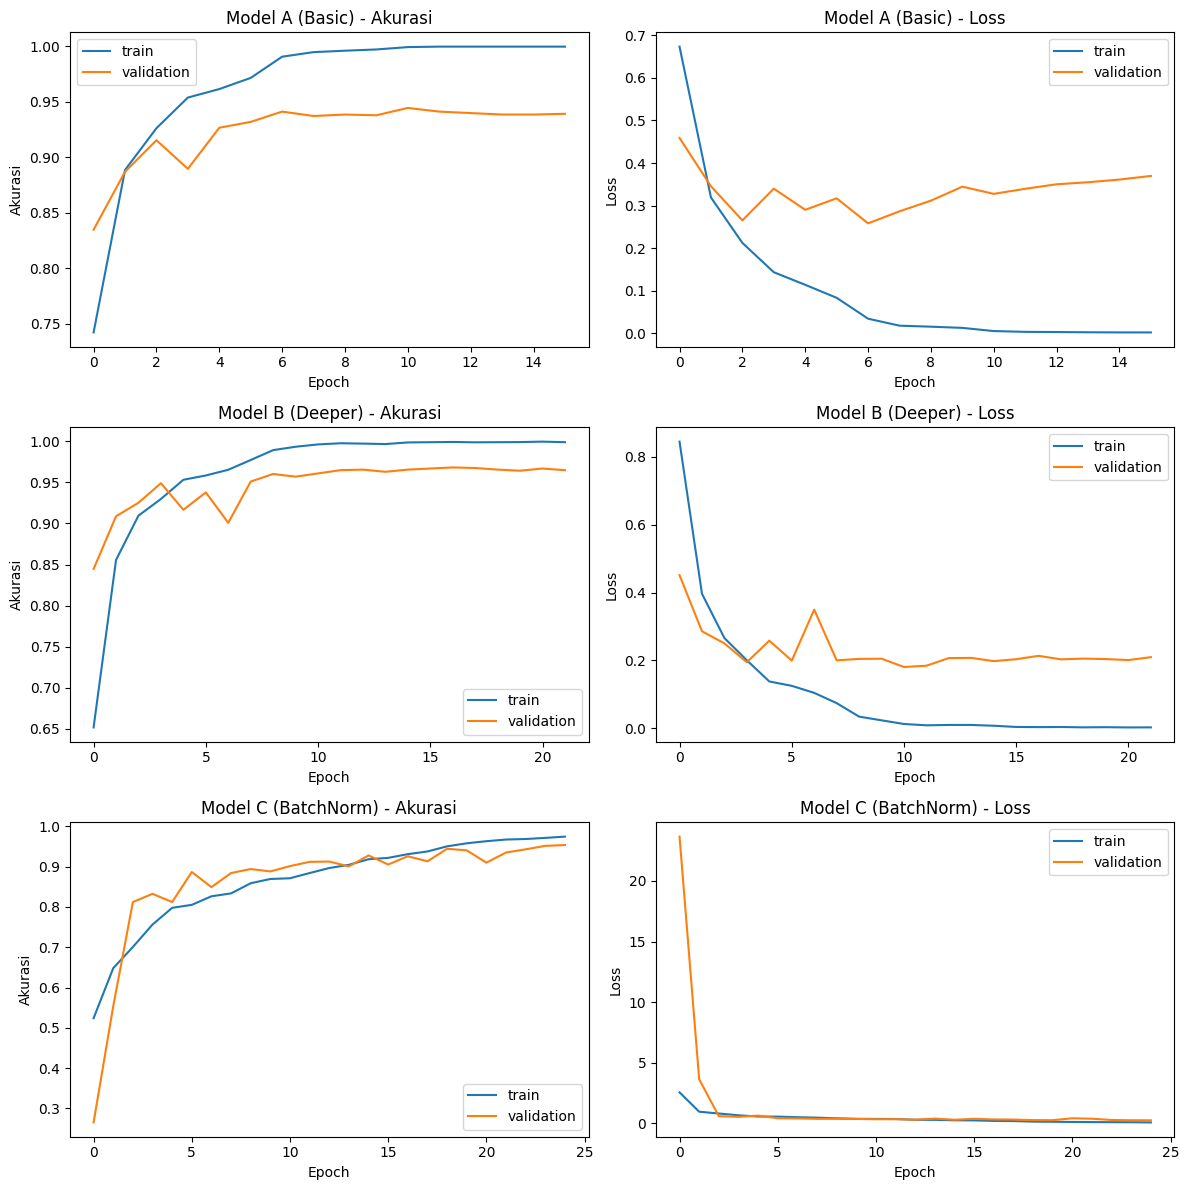

In [ ]:
fig, axes = plt.subplots(len(histories), 2, figsize=(12, 4 * len(histories)))

for i, (name, history) in enumerate(histories.items()):
    ax_acc = axes[i, 0]
    ax_acc.plot(history.history["accuracy"], label="train")
    ax_acc.plot(history.history["val_accuracy"], label="validation")
    ax_acc.set_title(f"{name} - Akurasi")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Akurasi")
    ax_acc.legend()

    ax_loss = axes[i, 1]
    ax_loss.plot(history.history["loss"], label="train")
    ax_loss.plot(history.history["val_loss"], label="validation")
    ax_loss.set_title(f"{name} - Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

plt.tight_layout()
plt.show()

## **12.   Classification report & confusion matrix**

--------------------------------------------------
Evaluasi Detail untuk Model A (Basic)
--------------------------------------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 405ms/step

Classification Report:
              precision    recall  f1-score   support

Botol Bening       0.95      0.93      0.94       378
 Botol Warna       0.93      0.94      0.93       378
      Kaleng       0.97      0.96      0.96       378
 Tutup Botol       0.95      0.97      0.96       378

    accuracy                           0.95      1512
   macro avg       0.95      0.95      0.95      1512
weighted avg       0.95      0.95      0.95      1512


Confusion Matrix:
[[351  15   7   5]
 [  8 354   2  14]
 [  9   7 361   1]
 [  2   5   4 367]]


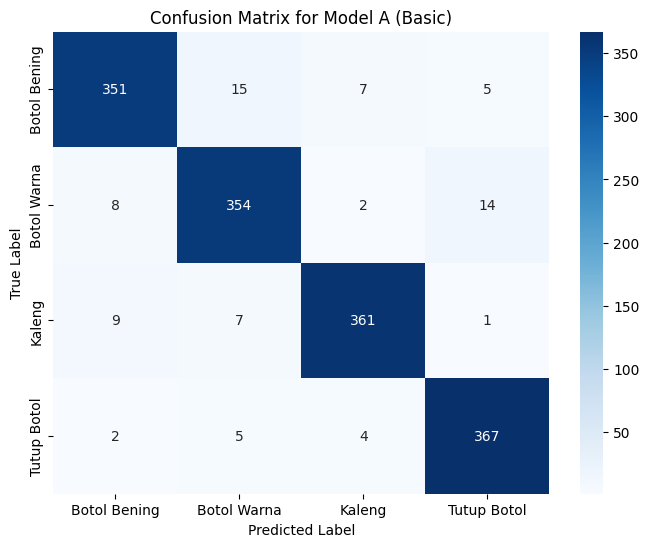



--------------------------------------------------
Evaluasi Detail untuk Model B (Deeper)
--------------------------------------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step

Classification Report:
              precision    recall  f1-score   support

Botol Bening       0.96      0.96      0.96       378
 Botol Warna       0.96      0.94      0.95       378
      Kaleng       0.98      0.97      0.97       378
 Tutup Botol       0.96      0.99      0.98       378

    accuracy                           0.97      1512
   macro avg       0.97      0.97      0.97      1512
weighted avg       0.97      0.97      0.97      1512


Confusion Matrix:
[[363   7   4   4]
 [  9 356   3  10]
 [  6   4 368   0]
 [  1   2   2 373]]


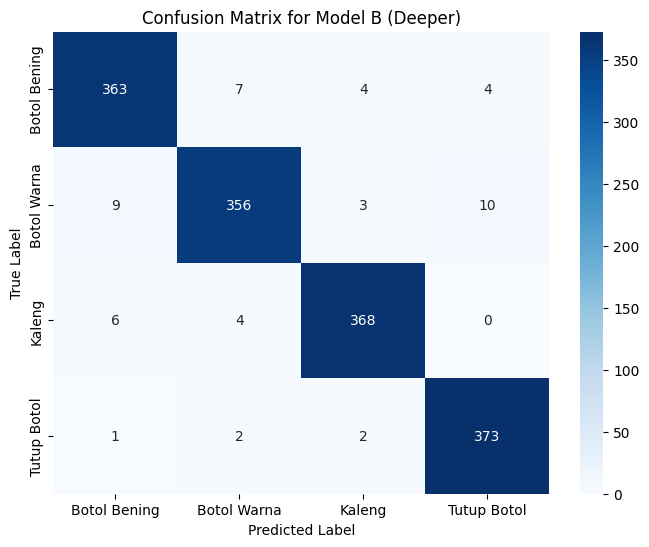



--------------------------------------------------
Evaluasi Detail untuk Model C (BatchNorm)
--------------------------------------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step

Classification Report:
              precision    recall  f1-score   support

Botol Bening       0.97      0.94      0.96       378
 Botol Warna       0.94      0.95      0.94       378
      Kaleng       0.98      0.97      0.98       378
 Tutup Botol       0.96      0.98      0.97       378

    accuracy                           0.96      1512
   macro avg       0.96      0.96      0.96      1512
weighted avg       0.96      0.96      0.96      1512


Confusion Matrix:
[[357  13   6   2]
 [  6 358   2  12]
 [  3   6 368   1]
 [  3   5   0 370]]


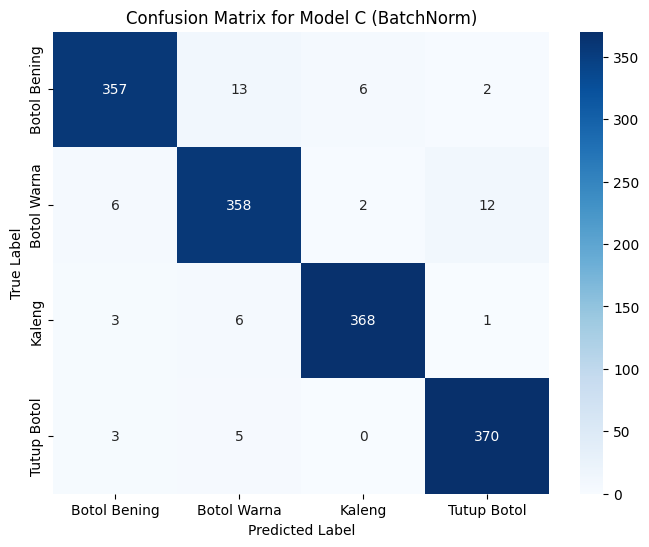

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Mengumpulkan true labels dari test_ds
y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

for name, res in results.items():
    print("-" * 50)
    print(f"Evaluasi Detail untuk {name}")
    print("-" * 50)

    model = res["model"]

    # Mendapatkan prediksi untuk test_ds
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    print("\n")

## **12.   Bandingkan hasil & pilih model terbaik**

In [28]:
import numpy as np
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Mengumpulkan true labels dari test_ds (memastikan ketersediaan di sel ini)
print("Perbandingan Model")
print("Mengumpulkan true labels dari test dataset...")
y_true_list = []
for _, labels in test_ds:
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true_list)
print("True labels berhasil dikumpulkan.")

print(f"{'Model':<22s} {'Test Accuracy':>15s} {'Test Loss':>12s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
print("-" * 85)

for name, res in results.items():
    model = res["model"]

    # Mendapatkan prediksi untuk test_ds
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate additional metrics
    accuracy = res['test_acc']
    loss = res['test_loss']
    # Use 'macro' average for multi-class classification to treat all classes equally
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"{name:<22s} {accuracy*100:14.2f}% {loss:12.4f} {precision:10.4f} {recall:10.4f} {f1:10.4f}")

best_name = max(results, key=lambda k: results[k]["test_acc"])
best_model = results[best_name]["model"]
print(f"\nModel terbaik: {best_name} dengan test accuracy {results[best_name]['test_acc']*100:.2f}%")

Perbandingan Model
Mengumpulkan true labels dari test dataset...
True labels berhasil dikumpulkan.
Model                    Test Accuracy    Test Loss  Precision     Recall   F1-Score
-------------------------------------------------------------------------------------
Model A (Basic)                 94.78%       0.3059     0.9478     0.9478     0.9477
Model B (Deeper)                96.56%       0.1722     0.9656     0.9656     0.9655
Model C (BatchNorm)             96.10%       0.2184     0.9611     0.9610     0.9610

Model terbaik: Model B (Deeper) dengan test accuracy 96.56%


## **13.   Simpan model terbaik ke format SavedModel**

In [29]:
SAVED_MODEL_DIR = "/content/submission/saved_model"
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
best_model.export(SAVED_MODEL_DIR)
print("SavedModel disimpan di:", SAVED_MODEL_DIR)

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138392638689872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638689488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638687952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638689680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638690640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638691024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638690832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638691792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138392638691216: TensorSpec(shape=(), dtype=tf.resource, name=None

## **14.   Konversi ke TF-Lite**

In [30]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
tflite_model = converter.convert()

TFLITE_DIR = "/content/submission/tflite"
os.makedirs(TFLITE_DIR, exist_ok=True)

tflite_path = os.path.join(TFLITE_DIR, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

label_path = os.path.join(TFLITE_DIR, "label.txt")
with open(label_path, "w") as f:
    for c in class_names:
        f.write(c + "\n")

print("TF-Lite model disimpan di:", tflite_path)
print("Label disimpan di:", label_path)

TF-Lite model disimpan di: /content/submission/tflite/model.tflite
Label disimpan di: /content/submission/tflite/label.txt


## **15.   Konversi ke TFJS**

In [31]:
TFJS_DIR = "/content/submission/tfjs_model"
os.makedirs(TFJS_DIR, exist_ok=True)

!tensorflowjs_converter --input_format=tf_saved_model {SAVED_MODEL_DIR} {TFJS_DIR}

print("TFJS model disimpan di:", TFJS_DIR)

2026-07-05 15:16:31.289038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783264591.534140   59620 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783264591.597799   59620 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783264591.900008   59620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783264591.900086   59620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783264591.900093   59620 computation_placer.cc:177] computation placer alr

## **16.   Inference Model**

Mengumpulkan satu contoh gambar per kelas untuk inferensi...
Selesai mengumpulkan sampel. Menampilkan hasil inferensi.


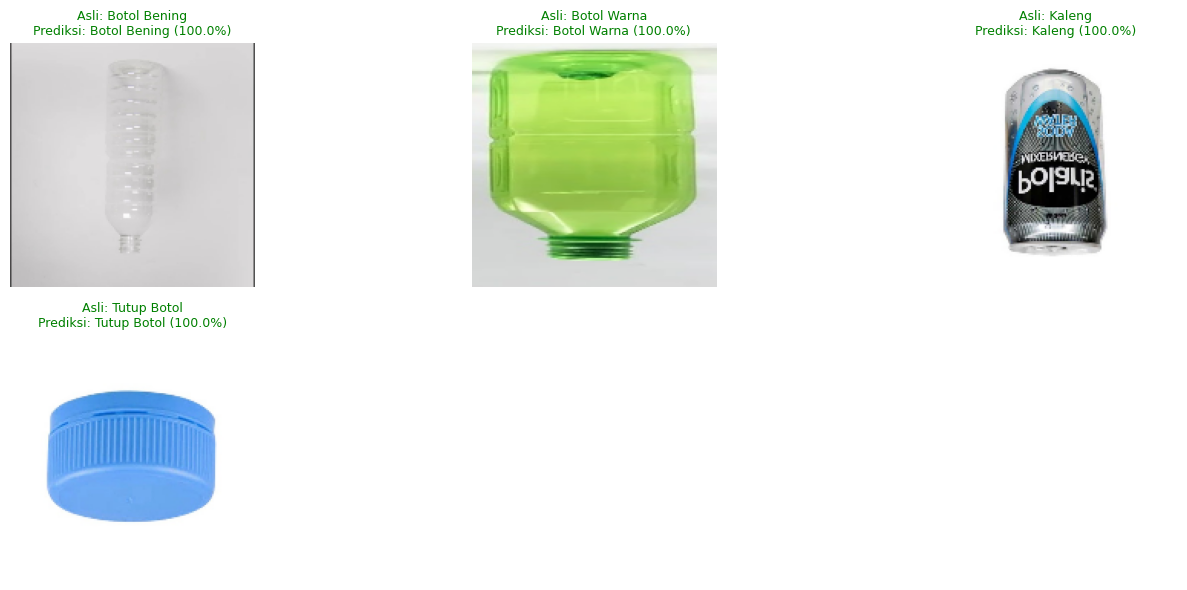

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Kamus untuk menyimpan satu gambar per kelas
sample_images_per_class = {}

print("Mengumpulkan satu contoh gambar per kelas untuk inferensi...")

# Iterasi melalui test_ds untuk mengumpulkan satu sampel per kelas
for images, labels in test_ds:
    for i in range(len(images)):
        img = images[i].numpy()
        true_idx = np.argmax(labels[i].numpy())
        class_name = class_names[true_idx]

        if class_name not in sample_images_per_class:
            # Lakukan inferensi untuk gambar ini
            pred = best_model.predict(np.expand_dims(img, axis=0), verbose=0)
            pred_idx = np.argmax(pred[0])
            confidence = pred[0][pred_idx] * 100

            sample_images_per_class[class_name] = {
                'image': img,
                'true_idx': true_idx,
                'pred_idx': pred_idx,
                'confidence': confidence
            }

        # Berhenti jika kita telah mengumpulkan satu gambar untuk setiap kelas
        if len(sample_images_per_class) == len(class_names):
            break
    if len(sample_images_per_class) == len(class_names):
        break

print("Selesai mengumpulkan sampel. Menampilkan hasil inferensi.")

n_show = len(sample_images_per_class)
if n_show > 0:
    plt.figure(figsize=(14, 3 * ((n_show + 2) // 3))) # Sesuaikan ukuran gambar secara dinamis
    for i, (class_name, data) in enumerate(sample_images_per_class.items()):
        img = data['image']
        true_idx = data['true_idx']
        pred_idx = data['pred_idx']
        confidence = data['confidence']

        ax = plt.subplot((n_show + 2) // 3, 3, i + 1)
        plt.imshow(img.astype("uint8"))
        color = "green" if pred_idx == true_idx else "red"
        plt.title(
            f"Asli: {class_names[true_idx]}\nPrediksi: {class_names[pred_idx]} ({confidence:.1f}%)",
            color=color,
            fontsize=9,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Tidak dapat mengumpulkan contoh gambar untuk semua kelas.")

## **17.   Buat requirements.txt**

In [ ]:
requirements = """tensorflow
tensorflowjs
split-folders
matplotlib
numpy
"""

req_path = "/content/submission/requirements.txt"
with open(req_path, "w") as f:
    f.write(requirements)

print("requirements.txt disimpan di:", req_path)

requirements.txt disimpan di: /content/submission/requirements.txt


## **18. Struktur folder submission akhir**

```
submission/
├── tfjs_model/
│   ├── group1-shard1of1.bin
│   └── model.json
├── tflite/
│   ├── model.tflite
│   └── label.txt
├── saved_model/
│   ├── saved_model.pb
│   └── variables/
├── notebook.ipynb   <- simpan/download notebook ini setelah dijalankan
├── README.md
└── requirements.txt
```
